In [2]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

#BASE_DIR  = Path('C:/Users/marce/F1-data-project/project/')
#FEAT_DIR  = '../../data/features'

# ── Cargar PC scores de telemetría ────────────────────────────────────────
df_scores = pl.read_parquet('../../data/features/telemetry_pca_v4.parquet').to_pandas()
pca       = joblib.load('../../data/features/pca_model_v4.pkl')

PC_COLS   = [c for c in df_scores.columns if c.startswith('PC')]
X_cluster = df_scores[PC_COLS].values
N_COMPONENTS = len(PC_COLS)

print(f'Shape para clustering: {X_cluster.shape}')
print(f'Componentes PCA: {PC_COLS}')

Shape para clustering: (3004, 6)
Componentes PCA: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']


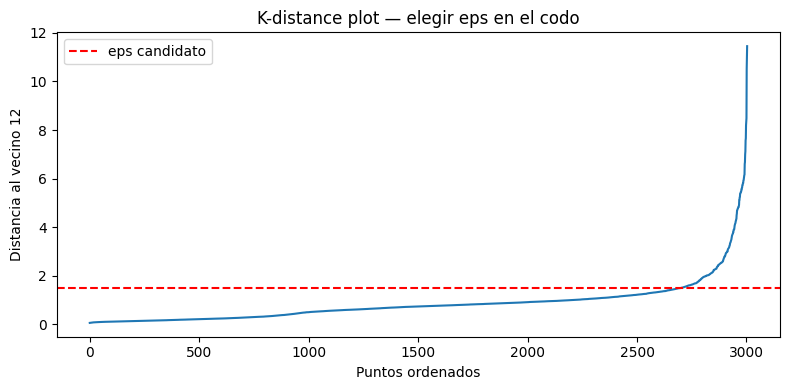

Clusters encontrados : 5
Puntos ruido (-1)    : 180 (6.0%)


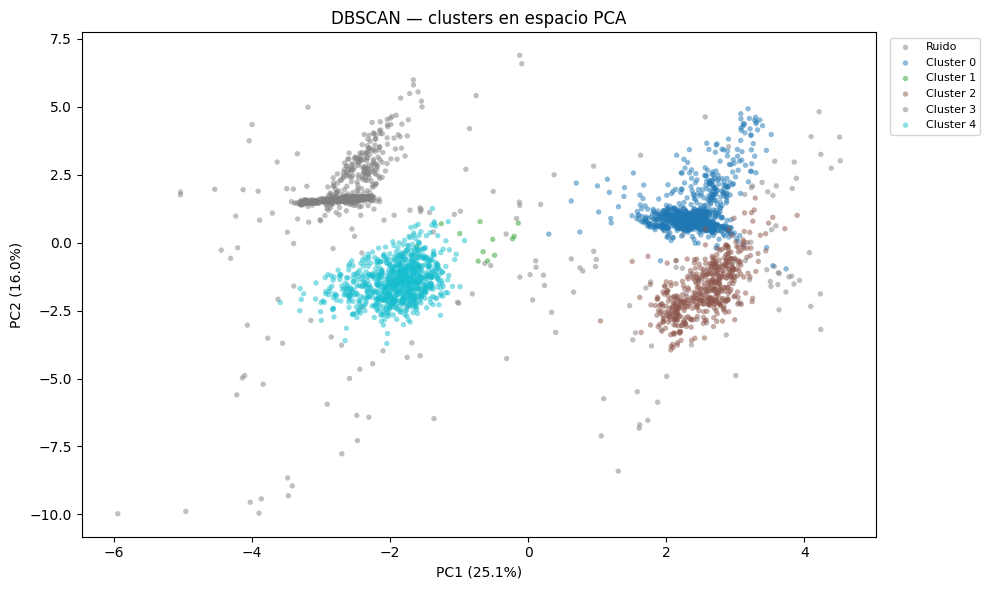

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# ── Usar los primeros N_COMPONENTS del PCA ────────────────────────────────
X_cluster = df_scores[PC_COLS].values  # ya está en el espacio PCA

# ── Paso 1: k-distance plot para elegir eps ───────────────────────────────
# Regla: k = 2 * n_componentes
k = 2 * N_COMPONENTS
nbrs = NearestNeighbors(n_neighbors=k).fit(X_cluster)
distances, _ = nbrs.kneighbors(X_cluster)
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.axhline(y=1.5, color='r', linestyle='--', label='eps candidato')
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {k}')
plt.title('K-distance plot — elegir eps en el codo')
plt.legend()
plt.tight_layout()
plt.show()

# ── Paso 2: DBSCAN con parámetros iniciales ───────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=k)
labels = dbscan.fit_predict(X_cluster)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f'Clusters encontrados : {n_clusters}')
print(f'Puntos ruido (-1)    : {n_noise} ({n_noise/len(labels):.1%})')

# ── Paso 3: Scatter coloreado por cluster ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

for label in sorted(set(labels)):
    mask = labels == label
    color = 'gray' if label == -1 else palette[label % 10]
    name  = 'Ruido' if label == -1 else f'Cluster {label}'
    ax.scatter(X_cluster[mask, 0], X_cluster[mask, 1],
               c=[color], label=name, alpha=0.5, s=15, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('DBSCAN — clusters en espacio PCA')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()